# BundesPredict — Exploratory Data Analysis

Sanity-checks the ingested Bundesliga data (2019/20–2025/26): home advantage, goal distributions, and basic integrity. Reads straight from Postgres through the data layer, so this doubles as proof the Phase 1 pipeline works end to end.

Run the stack first (`docker compose -f infra/docker-compose.yml up -d db`) and ingest (`python -m bundespredict.data.ingest`).

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
from bundespredict.data.db import make_engine

engine = make_engine()
query = '''
    SELECT m.season, m.date, ht.name AS home, at.name AS away,
           m.home_goals, m.away_goals, m.ftr,
           m.b365_home, m.b365_draw, m.b365_away
    FROM matches m
    JOIN teams ht ON ht.id = m.home_id
    JOIN teams at ON at.id = m.away_id
    ORDER BY m.date
'''
df = pd.read_sql(query, engine, parse_dates=['date'])
df['total_goals'] = df['home_goals'] + df['away_goals']
df.shape

Matplotlib is building the font cache; this may take a moment.


(2142, 11)

## Overview

In [2]:
print('matches :', len(df))
print('seasons :', sorted(df.season.unique()))
print('teams   :', df.home.nunique())
df.head()

matches : 2142
seasons : ['1920', '2021', '2122', '2223', '2324', '2425', '2526']
teams   : 27


,season,date,home,away,home_goals,away_goals,ftr,b365_home,b365_draw,b365_away,total_goals
0,1920,2019-08-16,Bayern Munich,Hertha BSC,2,2,D,1.14,8.00,15.00,4
1,1920,2019-08-17,Borussia Dortmund,FC Augsburg,5,1,H,1.20,7.00,13.00,6
2,1920,2019-08-17,SC Freiburg,1.FSV Mainz 05,3,0,H,2.25,3.25,3.40,3
3,1920,2019-08-17,Bayer 04 Leverkusen,SC Paderborn 07,3,2,H,1.25,6.00,12.00,5
4,1920,2019-08-17,SV Werder Bremen,Fortuna Düsseldorf,1,3,A,1.75,3.75,4.75,4


## Home advantage

The single biggest standing effect in football. Expect home-win rate well above 1/3.

ftr
home    0.432
away    0.320
draw    0.247
Name: proportion, dtype: float64


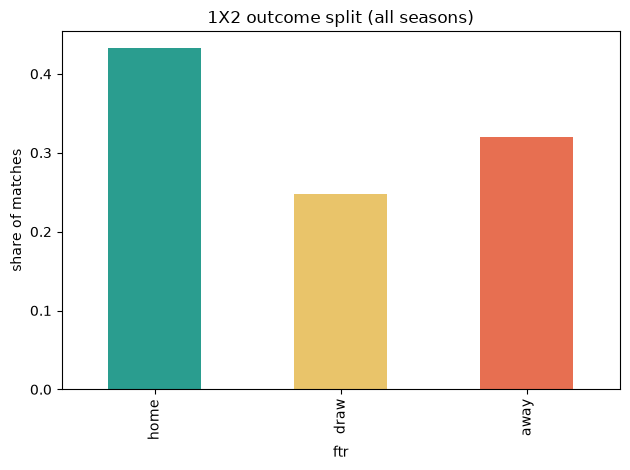

In [3]:
rates = df.ftr.value_counts(normalize=True).rename({'H':'home','D':'draw','A':'away'})
print(rates.round(3))
ax = rates.loc[['home','draw','away']].plot.bar(color=['#2a9d8f','#e9c46a','#e76f51'])
ax.set_ylabel('share of matches'); ax.set_title('1X2 outcome split (all seasons)')
plt.tight_layout()

season
1920    0.402
2021    0.422
2122    0.467
2223    0.474
2324    0.438
2425    0.386
2526    0.438
Name: home_win, dtype: float64

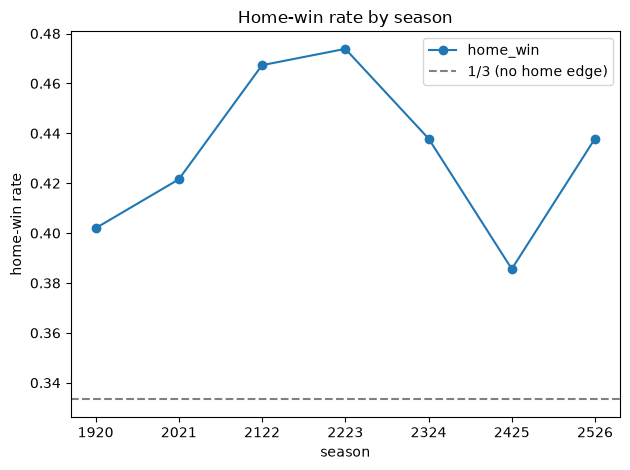

In [4]:
by_season = df.assign(home_win=df.ftr.eq('H')).groupby('season').home_win.mean()
ax = by_season.plot(marker='o')
ax.axhline(1/3, ls='--', color='grey', label='1/3 (no home edge)')
ax.set_ylabel('home-win rate'); ax.set_title('Home-win rate by season'); ax.legend()
plt.tight_layout()
by_season.round(3)

## Goal distributions

The Poisson core assumes goals are roughly Poisson-distributed; eyeball the shape and per-side means (home mean should exceed away).

In [5]:
print(df[['home_goals','away_goals','total_goals']].describe().round(2))
print('\nmean home goals:', round(df.home_goals.mean(), 3))
print('mean away goals:', round(df.away_goals.mean(), 3))

       home_goals  away_goals  total_goals
count     2142.00     2142.00      2142.00
mean         1.74        1.42         3.16
std          1.42        1.26         1.74
min          0.00        0.00         0.00
25%          1.00        0.00         2.00
50%          1.00        1.00         3.00
75%          3.00        2.00         4.00
max          8.00        7.00        10.00

mean home goals: 1.739
mean away goals: 1.422


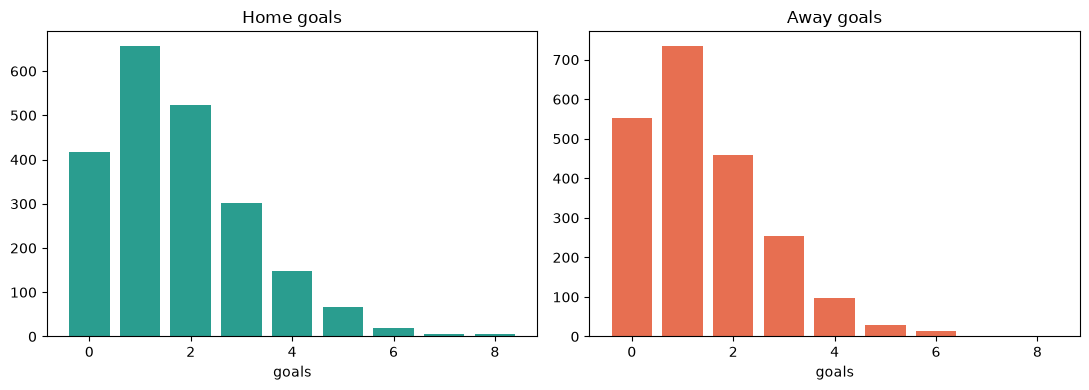

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
maxg = int(df[['home_goals','away_goals']].max().max())
bins = range(0, maxg + 2)
axes[0].hist(df.home_goals, bins=bins, align='left', rwidth=0.8, color='#2a9d8f')
axes[0].set_title('Home goals'); axes[0].set_xlabel('goals')
axes[1].hist(df.away_goals, bins=bins, align='left', rwidth=0.8, color='#e76f51')
axes[1].set_title('Away goals'); axes[1].set_xlabel('goals')
plt.tight_layout()

## Integrity checks

Belt-and-suspenders on top of the ingest tests: no null scores, and the stored result (FTR) always agrees with the goals.

In [7]:
assert df[['home_goals','away_goals']].notna().all().all(), 'null scores present'
import numpy as np
implied = np.sign(df.home_goals - df.away_goals).map({1:'H', 0:'D', -1:'A'})
mismatch = (implied != df.ftr).sum()
print('FTR/score mismatches:', mismatch)
assert mismatch == 0
print('all integrity checks passed')

FTR/score mismatches: 0
all integrity checks passed
